In [39]:
import numpy as np
import pandas as pd
from rich.jupyter import display
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [40]:
sns.set_style('whitegrid')

In [41]:
df = pd.read_csv('../dataset/red-wine.csv')

In [42]:
df.shape

(1599, 12)

In [43]:
X = df.drop('quality', axis=1)
y = df['quality']

<Axes: title={'center': 'Spearman Correlation with Target'}>

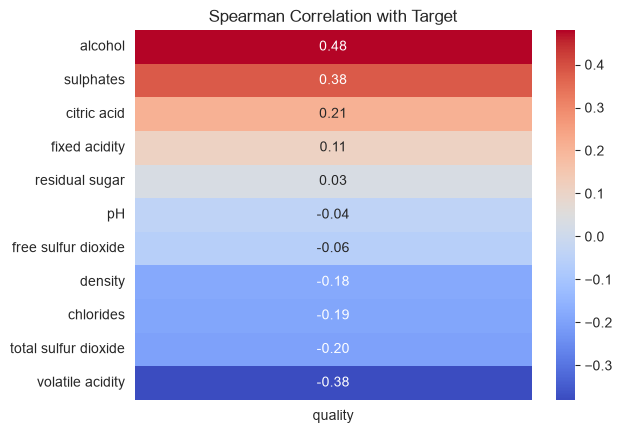

In [44]:
sp_stat, p_value = stats.spearmanr(X, y)

labels = X.columns.tolist() + ['quality']

corr = pd.DataFrame(data=sp_stat, columns=labels, index=labels)

# correlation of each feature with the target only
target_corr = corr['quality'].drop('quality').round(2).sort_values(ascending=False)

plt.title('Spearman Correlation with Target')
sns.heatmap(target_corr.to_frame(), annot=True, cmap='coolwarm', fmt='.2f')

<Axes: title={'center': 'Pearson Correlation with Target'}>

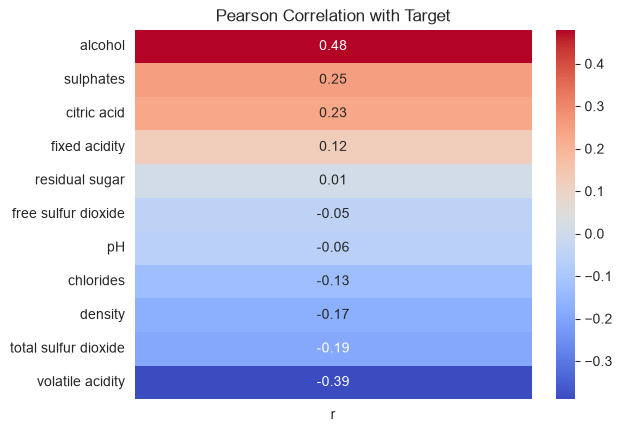

In [45]:
# pearsonr works on a pair of 1-D arrays, so apply it column by column
pearson = X.apply(lambda col: pd.Series(stats.pearsonr(col, y), index=['r', 'p_value']))
target_corr = pearson.loc['r'].round(2).sort_values(ascending=False)

plt.title('Pearson Correlation with Target')
sns.heatmap(target_corr.to_frame(), annot=True, cmap='coolwarm', fmt='.2f')

## Mutual Information Test

<Axes: title={'center': 'Mutual Information'}, ylabel='feature'>

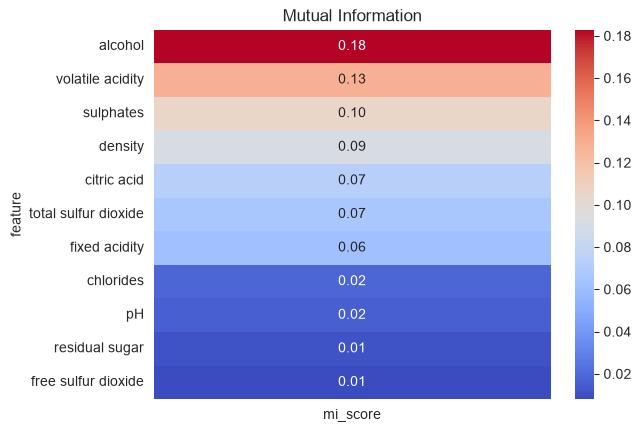

In [46]:
mi_score = mutual_info_classif(X, y, random_state=42)

df = pd.DataFrame({'feature': X.columns, 'mi_score': mi_score}).sort_values(by='mi_score', ascending=False)

plt.title('Mutual Information')
sns.heatmap(df.set_index('feature'), annot=True, cmap='coolwarm', fmt='.2f')

## Combine all statistical tests into a single dataframe

In [47]:
stat_df = pd.DataFrame({
    'feature': X.columns,
    'spearman_corr': target_corr.values,
    'pearson_corr': pearson.loc['r'].values,
    'mi_score': mi_score
}).sort_values(by='mi_score', ascending=False)

# display the dataframe
display(stat_df)

,feature,spearman_corr,pearson_corr,mi_score
10,alcohol,-0.39,0.476166,0.182962
1,volatile acidity,0.25,-0.390558,0.128808
9,sulphates,-0.19,0.251397,0.104431
7,density,-0.13,-0.174919,0.091515
2,citric acid,0.23,0.226373,0.073496
6,total sulfur dioxide,-0.06,-0.185100,0.066747
0,fixed acidity,0.48,0.124052,0.061334
4,chlorides,0.01,-0.128907,0.018590
8,pH,-0.17,-0.057731,0.015699
3,residual sugar,0.12,0.013732,0.010834


## Let's use FeatureImportance as additional test to compare with the statistical tests

In [48]:
from sklearn.ensemble import RandomForestClassifier

estimator = RandomForestClassifier(n_estimators=100, random_state=42)

estimator.fit(X, y)

feature_importance = estimator.feature_importances_

stat_df['feature_importance'] = feature_importance

In [49]:
## Create rank for all three tests ( using absolute values for correlation tests)

In [50]:
stat_df['spearman_rank'] = stat_df['spearman_corr'].abs().rank(ascending=False)
stat_df['pearson_rank'] = stat_df['pearson_corr'].abs().rank(ascending=False)
stat_df['mi_rank'] = stat_df['mi_score'].rank(ascending=False)
stat_df['feature_importance_rank'] = stat_df['feature_importance'].rank(ascending=False)

stat_df['rank_sum'] = stat_df[['spearman_rank', 'pearson_rank', 'mi_rank', 'feature_importance_rank']].sum(axis=1)

# display the dataframe
display(stat_df.sort_values(by='rank_sum'))

,feature,spearman_corr,pearson_corr,mi_score,feature_importance,spearman_rank,pearson_rank,mi_rank,feature_importance_rank,rank_sum
10,alcohol,-0.39,0.476166,0.182962,0.075535,2.0,1.0,1.0,7.0,11.0
1,volatile acidity,0.25,-0.390558,0.128808,0.100606,3.0,2.0,2.0,4.0,11.0
0,fixed acidity,0.48,0.124052,0.061334,0.103722,1.0,8.0,7.0,3.0,19.0
2,citric acid,0.23,0.226373,0.073496,0.078535,4.0,4.0,5.0,6.0,19.0
9,sulphates,-0.19,0.251397,0.104431,0.074150,5.0,3.0,3.0,9.0,20.0
7,density,-0.13,-0.174919,0.091515,0.072882,7.0,6.0,4.0,10.0,27.0
6,total sulfur dioxide,-0.06,-0.185100,0.066747,0.066172,9.0,5.0,6.0,11.0,31.0
4,chlorides,0.01,-0.128907,0.018590,0.088905,11.0,7.0,8.0,5.0,31.0
3,residual sugar,0.12,0.013732,0.010834,0.112402,8.0,11.0,10.0,2.0,31.0
8,pH,-0.17,-0.057731,0.015699,0.075392,6.0,9.0,9.0,8.0,32.0


## DataSet Preparation ( split train and test set)

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

In [52]:
# Train on all features

estimator = RandomForestClassifier(n_estimators=50, random_state=42)

estimator.fit(X_train, y_train)

# use cros_val_score to evaluate the model on the training set
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator, X_train, y_train, cv=5, n_jobs=-1, scoring='accuracy')

print(f'Cross-validation accuracy scores: {scores}')
print(f'Mean cross-validation accuracy: {scores.mean():.4f}')

Cross-validation accuracy scores: [0.65277778 0.67013889 0.64930556 0.68402778 0.65156794]
Mean cross-validation accuracy: 0.6616


In [53]:
# Evaluate on the test set
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = estimator.predict(X_test)

print(f'Test set accuracy: {accuracy_score(y_test, y_pred):.4f}')


Test set accuracy: 0.7188


In [58]:
# Decrease of features
required_num_features = 4
top_features = stat_df.sort_values(by='rank_sum').head(required_num_features)['feature'].tolist()

estimator = RandomForestClassifier(n_estimators=50, random_state=42)
estimator.fit(X_train[top_features], y_train)

# use cros_val_score to evaluate the model on the training set
scores = cross_val_score(estimator,
                         X_train[top_features],
                         y_train,
                         cv=5,
                         n_jobs=-1, scoring='accuracy')

print(f'Cross-validation accuracy scores: {scores}')
print(f'Mean cross-validation accuracy: {scores.mean():.4f}')

Cross-validation accuracy scores: [0.61805556 0.68402778 0.64930556 0.64930556 0.65505226]
Mean cross-validation accuracy: 0.6511


In [59]:
y_pred = estimator.predict(X_test[top_features])

print(f'Test set accuracy: {accuracy_score(y_test, y_pred):.4f}')

Test set accuracy: 0.7125


In [65]:
result = {
    'n_features': [],
    'mean_cv_accuracy': [],
    'test_accuracy': []}
for n_features in range(len(X.columns), 0, -1):
    print(f'Training with top {n_features} features...')
    top_features = stat_df.sort_values(by='feature_importance_rank').head(n_features)['feature'].tolist()

    estimator = RandomForestClassifier(n_estimators=50, random_state=42)
    estimator.fit(X_train[top_features], y_train)

    # use cros_val_score to evaluate the model on the training set
    scores = cross_val_score(estimator,
                             X_train[top_features],
                             y_train,
                             cv=5,
                             n_jobs=-1, scoring='accuracy')

    y_pred = estimator.predict(X_test[top_features])

    result['n_features'].append(n_features)
    result['mean_cv_accuracy'].append(scores.mean())
    result['test_accuracy'].append(accuracy_score(y_test, y_pred))

df = pd.DataFrame(result)
display(df)

Training with top 11 features...
Training with top 10 features...
Training with top 9 features...
Training with top 8 features...
Training with top 7 features...
Training with top 6 features...
Training with top 5 features...
Training with top 4 features...
Training with top 3 features...
Training with top 2 features...
Training with top 1 features...


,n_features,mean_cv_accuracy,test_accuracy
0,11,0.660172,0.75000
1,10,0.657385,0.75625
2,9,0.652516,0.76250
3,8,0.651832,0.71875
4,7,0.647651,0.75000
5,6,0.599683,0.68750
6,5,0.592736,0.70000
7,4,0.578150,0.73750
8,3,0.555212,0.60625
9,2,0.475999,0.50625


In [63]:
result = {
    'n_features': [],
    'mean_cv_accuracy': [],
    'test_accuracy': []}
for n_features in range(len(X.columns), 0, -1):
    print(f'Training with top {n_features} features...')
    top_features = stat_df.sort_values(by='mi_rank').head(n_features)['feature'].tolist()

    estimator = RandomForestClassifier(n_estimators=50, random_state=42)
    estimator.fit(X_train[top_features], y_train)

    # use cros_val_score to evaluate the model on the training set
    scores = cross_val_score(estimator,
                             X_train[top_features],
                             y_train,
                             cv=5,
                             n_jobs=-1, scoring='accuracy')

    y_pred = estimator.predict(X_test[top_features])

    result['n_features'].append(n_features)
    result['mean_cv_accuracy'].append(scores.mean())
    result['test_accuracy'].append(accuracy_score(y_test, y_pred))

df = pd.DataFrame(result)
display(df)

Training with top 11 features...
Training with top 10 features...
Training with top 9 features...
Training with top 8 features...
Training with top 7 features...
Training with top 6 features...
Training with top 5 features...
Training with top 4 features...
Training with top 3 features...
Training with top 2 features...
Training with top 1 features...


,n_features,mean_cv_accuracy,test_accuracy
0,11,0.670591,0.75625
1,10,0.665026,0.73750
2,9,0.669212,0.76875
3,8,0.675469,0.74375
4,7,0.660172,0.75000
5,6,0.660163,0.70625
6,5,0.660167,0.75625
7,4,0.633062,0.73750
8,3,0.621929,0.70000
9,2,0.567037,0.59375


In [64]:
result = {
    'n_features': [],
    'mean_cv_accuracy': [],
    'test_accuracy': []}
for n_features in range(len(X.columns), 0, -1):
    print(f'Training with top {n_features} features...')
    top_features = stat_df.sort_values(by='rank_sum').head(n_features)['feature'].tolist()

    estimator = RandomForestClassifier(n_estimators=50, random_state=42)
    estimator.fit(X_train[top_features], y_train)

    # use cros_val_score to evaluate the model on the training set
    scores = cross_val_score(estimator,
                             X_train[top_features],
                             y_train,
                             cv=5,
                             n_jobs=-1, scoring='accuracy')

    y_pred = estimator.predict(X_test[top_features])

    result['n_features'].append(n_features)
    result['mean_cv_accuracy'].append(scores.mean())
    result['test_accuracy'].append(accuracy_score(y_test, y_pred))

df = pd.DataFrame(result)
display(df)

Training with top 11 features...
Training with top 10 features...
Training with top 9 features...
Training with top 8 features...
Training with top 7 features...
Training with top 6 features...
Training with top 5 features...
Training with top 4 features...
Training with top 3 features...
Training with top 2 features...
Training with top 1 features...


,n_features,mean_cv_accuracy,test_accuracy
0,11,0.671291,0.73750
1,10,0.659485,0.77500
2,9,0.665735,0.75625
3,8,0.671961,0.75000
4,7,0.662258,0.74375
5,6,0.658089,0.72500
6,5,0.652524,0.74375
7,4,0.651149,0.71250
8,3,0.631661,0.75625
9,2,0.567037,0.59375
